In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# =============
# 2. Load Dataset
# =============

wine = load_wine()

X = wine.data
feature_names = wine.feature_names

# Convert to DataFrame
df = pd.DataFrame(X, columns=feature_names)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (178, 13)

First 5 rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_dilu

In [7]:
# =============
# 3. Select Two Features for Visualization
# =============
# we select two features
# for direct 2D visualization

selected_features = ['alcohol', 'malic_acid']
X_selected = df[selected_features].values

print("\nSelected Features:", selected_features)


Selected Features: ['alcohol', 'malic_acid']


In [8]:
# ================
# 4. Feature Scaling
# ================
# Important because K-Means uses distance calculations

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

print("Feature scaling completed.")

Feature scaling completed.


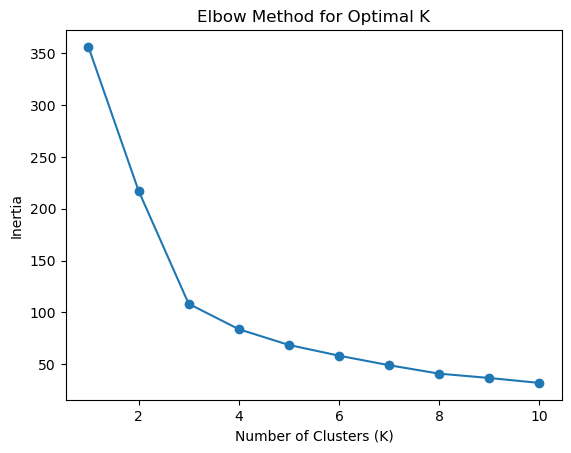

In [9]:
# 5. Finding Optimal Number of Clusters (Elbow Method)
# ======================
inertia_values = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

# Plot elbow curve
plt.figure()
plt.plot(K_range, inertia_values, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

In [10]:
# ===================
# 6. Train K-Means Model
# ===================
# Assume optimal clusters = 3 from elbow method

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

# Add cluster Labels
df['cluster'] = clusters

print("\nCluster Centers (Scaled Values):")
print(kmeans.cluster_centers_)


Cluster Centers (Scaled Values):
[[-0.98858319 -0.5829103 ]
 [ 0.09906621  1.41480748]
 [ 0.87009843 -0.493973  ]]


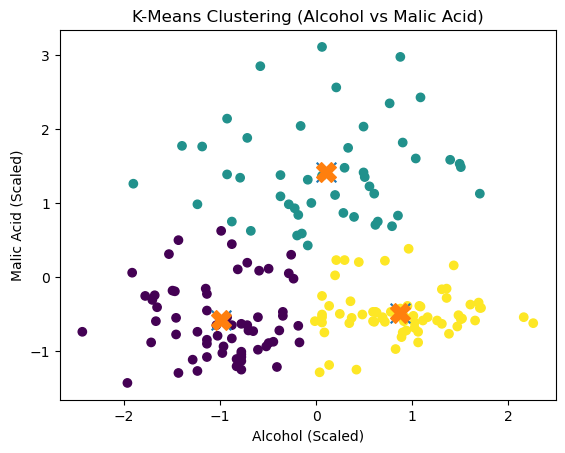

In [11]:
# ===========================================
# 7. Visualizing Clusters
# ===========================================
plt.figure()

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters
)

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker='x',
    s=200
)

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker='X',
    s=200
)

plt.title("K-Means Clustering (Alcohol vs Malic Acid)")
plt.xlabel("Alcohol (Scaled)")
plt.ylabel("Malic Acid (Scaled)")
plt.show()

In [13]:
# =====================
# 8. Evaluating Clustering Performance
# =====================
# Internal evaluation metric

sil_score = silhouette_score(X_scaled, clusters)

print("\nSilhouette Score:", sil_score)

"""

Interpretation:
- Value close to +1 → good cluster separation
- Value near 0 → overlapping clusters
- Negative value → poor clustering
"""


Silhouette Score: 0.484095893654603


'\n\nInterpretation:\n- Value close to +1 → good cluster separation\n- Value near 0 → overlapping clusters\n- Negative value → poor clustering\n'

In [14]:
# ================
# 9. Cluster Distribution
# ====================
print("\nNumber of samples in each cluster:")
print(df['cluster'].value_counts())


Number of samples in each cluster:
cluster
2    66
0    63
1    49
Name: count, dtype: int64
